Progetto AOCR Stazioni Raccolta Sangue Campania


In [ ]:
!pip install osmnx gurobipy



In [ ]:
import osmnx as ox
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist
import pickle
import gurobipy
import time

Generazione Istanza

Dizionario Comuni

In [ ]:

ox.settings.use_cache = True
#Per l'Italia, admin_level=8 scarica i comuni

# Scarichiamo prima il poligono che rappresenta il confine della Campania, calcolo i confini cosi da filtrare i comuni cge non fanno parte della regione
regione_campania = ox.geocode_to_gdf("Campania, Italy")
regione_campania = regione_campania.to_crs(epsg=32633)
poligono_campania = regione_campania.geometry.iloc[0]

gdf_comuni = ox.features_from_place("Campania, Italy", tags={"admin_level": "8"})
gdf_comuni = gdf_comuni[gdf_comuni.geom_type.isin(['Polygon', 'MultiPolygon'])].to_crs(epsg=32633)


gdf_comuni = gdf_comuni.dropna(subset=['name'])
gdf_comuni = gdf_comuni.drop_duplicates(subset=['name'], keep='first')

gdf_comuni = gdf_comuni[gdf_comuni.centroid.within(poligono_campania)]



#for i in gdf_comuni['name']:
#   print(i)
#print(len(gdf_comuni['name']))




alpha = 0.035          # Tasso di donazione
np.random.seed(42)     # Seed random() uguale per ogni avvio

# Calcolo centroidi per ogni comuni, per rappresentarli come nodi

centroidi_metri = gdf_comuni.geometry.centroid
gdf_comuni['centroid'] = centroidi_metri.to_crs(epsg=4326)

comuni={}

for indice,riga in gdf_comuni.iterrows():
    nome_comune=riga['name']
    lat=riga['centroid'].y
    lon=riga['centroid'].x

    if nome_comune=="Napoli":
        pop_frazione= 962000/10
        sangue_frazione= pop_frazione*alpha

        for k in range(1,11):
            chiave_napoli= f"Napoli_{k}"
            spostamento_lat = np.random.uniform(0.009, 0.018)
            spostamento_lon = np.random.uniform(0.009, 0.018)
            # Usiamo random.choice per decidere se andare a Nord/Sud (+/-) e Est/Ovest (+/-)
            lat_var = lat + spostamento_lat * np.random.choice([-1, 1])
            lon_var = lon + spostamento_lon * np.random.choice([-1, 1])
            comuni[chiave_napoli]=[lat_var,lon_var,int(pop_frazione),sangue_frazione]
    else:
        popolazione = np.random.randint(2000, 50000)
        offerta_sangue = int(popolazione * alpha)
        comuni[nome_comune]=[lat,lon,popolazione,offerta_sangue]

#comuni
#len(comuni)
#Struttura dizionario comuni: Chiave -> Nome del Comune, Valore-> Lista [Latitudine,Longitudine,Popolazione,Relazione donatori-popolazione]


Generazione Centri

In [ ]:
tutti_i_comuni = list(comuni.keys())


#  22 comuni a caso senza(nessun comune può essere scelto due volte)
comuni_centri_scelti = np.random.choice(tutti_i_comuni, size=22, replace=False)

centri = {}
for idx, comune_scelto in enumerate(comuni_centri_scelti):
    nome_centro = f"Centro_{idx}"
    lat_centro = comuni[comune_scelto][0]
    lon_centro = comuni[comune_scelto][1]
    centri[nome_centro] = [lat_centro, lon_centro]

#centri

Calcolo Distanza Comuni-Centri e Centri-Centri


In [ ]:
dist_comuni_centri={}
dist_centri_centri={}

for i in comuni.keys():
    for j in centri.keys():
        dist= (((comuni[i][0] - centri[j][0])**2 + (comuni[i][1] - centri[j][1])**2)**0.5) * 111.3
        dist_comuni_centri[(i,j)] = dist

for i in centri.keys():
    for j in centri.keys():
        dist= (((centri[i][0] - centri[j][0])**2 + (centri[i][1] - centri[j][1])**2)**0.5) * 111.3
        dist_centri_centri[(i,j)] = dist


#dist_comuni_centri

nome_comuni_centri=[]
for i,j in dist_comuni_centri.items():
    if j<1:
        #print(i,j)
        nome_comuni_centri.append(i[0])

#nome_comuni_centri


dist_centri_centri
#len(dist_comuni_centri) -> 12298 -> 559 comuni * 22 centri
#len(dist_centri_centri) -> 462 _ 22*21 (N)*(N-1)


{('Centro_0', 'Centro_0'): 0.0,
 ('Centro_0', 'Centro_1'): 26.870036009363446,
 ('Centro_0', 'Centro_2'): 21.173970363080112,
 ('Centro_0', 'Centro_3'): 32.192760652761976,
 ('Centro_0', 'Centro_4'): 48.35831916753881,
 ('Centro_0', 'Centro_5'): 151.65201132483259,
 ('Centro_0', 'Centro_6'): 143.19961095978366,
 ('Centro_0', 'Centro_7'): 110.78844164967522,
 ('Centro_0', 'Centro_8'): 109.54356030291939,
 ('Centro_0', 'Centro_9'): 136.87438342385295,
 ('Centro_0', 'Centro_10'): 106.05921783350216,
 ('Centro_0', 'Centro_11'): 114.79506951348357,
 ('Centro_0', 'Centro_12'): 14.28398654133584,
 ('Centro_0', 'Centro_13'): 72.14960776971748,
 ('Centro_0', 'Centro_14'): 43.98516300473882,
 ('Centro_0', 'Centro_15'): 49.32846921591139,
 ('Centro_0', 'Centro_16'): 5.0526985790947165,
 ('Centro_0', 'Centro_17'): 7.2882014475660135,
 ('Centro_0', 'Centro_18'): 44.73672629144948,
 ('Centro_0', 'Centro_19'): 47.916797517485975,
 ('Centro_0', 'Centro_20'): 45.36136928630103,
 ('Centro_0', 'Centro_21

Stampa grafica del grafo

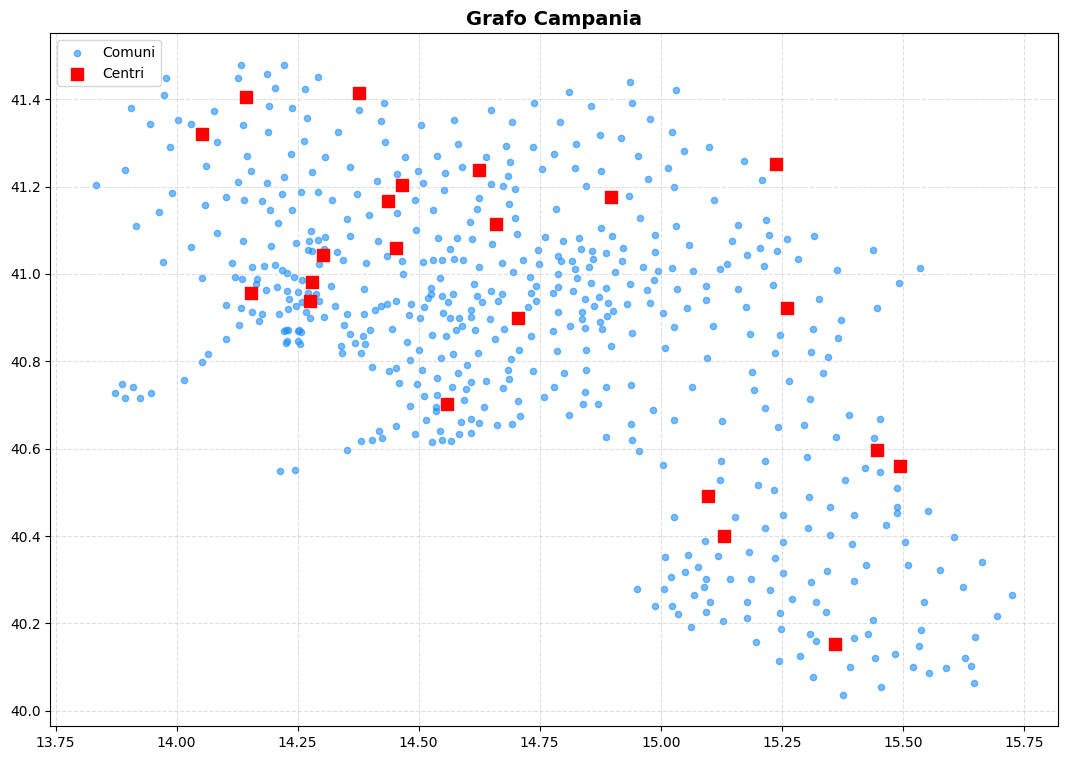

In [ ]:
import matplotlib.pyplot as plt


tutti_comuni_x = [comuni[i][1] for i in comuni.keys()]
tutti_comuni_y = [comuni[i][0] for i in comuni.keys()]


centri_x = [centri[j][1] for j in centri.keys()]
centri_y = [centri[j][0] for j in centri.keys()]


plt.figure(figsize=(13, 9))

#Comuni in Azzurro
plt.scatter(tutti_comuni_x, tutti_comuni_y, color='dodgerblue', s=20, alpha=0.6, label='Comuni')

#Centri in Rosso
plt.scatter(centri_x, centri_y, color='red', marker='s', s=80, zorder=3, label='Centri')

# Personalizzazione estetica della mappa
plt.title("Grafo Campania", fontsize=14, fontweight='bold')
plt.legend(loc='upper left', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.4)


plt.show()

![image.png](attachment:7b8566be-f37c-497b-afe3-7dc4474140d5.png)

In [ ]:
import gurobipy as gp
from gurobipy import GRB
conn={
    "WLSACCESSID":"131e88c7-3a80-45e9-8f34-3cb5116ef68c",
    "WLSSECRET":"5942d30a-4079-434c-924e-6bce44eac84f",
    "LICENSEID":2828935

}

env=gp.Env(params=conn)
model=gp.Model("Riorganizzazione_Sacca_Sangue", env=env)
import numpy as np
#parametri
I = list(comuni.keys())  # Nodi di domanda (559)
J = list(centri.keys())  # Nodi d'impianto candidati (22)

#distanza in km
raggio_donatori = 20.0      # Raggio per N_i e O_i
raggio_inter_centro = 40.0  # Raggio per M_j

# Costruzione degli insiemi basata sui tuoi dizionari delle distanze
N = {i: [j for j in J if dist_comuni_centri[(i, j)] <= raggio_donatori] for i in I}
O = {i: [j for j in J if dist_comuni_centri[(i, j)] <= raggio_inter_centro] for i in I}
M = {j: [j_prime for j_prime in J if j == j_prime or dist_centri_centri.get((j, j_prime), 999) <= raggio_inter_centro] for j in J}

# Parametri del Paper (Target e Costanti)
F = max(dist_comuni_centri.values())  # Massima distanza assoluta comune-centro
D = 500000                            # Target di autosufficienza regionale
C = 30000                             # Capacità massima di raccolta di una struttura
P_min = 40000                         # Produttività minima obbligatoria di un BC
tn = 150000                           # Budget massimo per la logistica mobile/riallocazione
lambda_penalita = 100000              # Peso della penale nella funzione obiettivo

# Dizionario dell'offerta a_i (Popolazione del comune * 0.035)
a = {i: comuni[i][2] * 0.035 for i in I}




# Node variables (binary)
y_s = model.addVars(J, vtype=GRB.BINARY, name="y_s")  # 1 se BS attiva in j
y_c = model.addVars(J, vtype=GRB.BINARY, name="y_c")  # 1 se BC attivo in j

# Assignment variables (binary)
x = model.addVars(I, J, vtype=GRB.BINARY, name="x")   # Assegnazione donatore i a centro j
z = model.addVars(I, J, vtype=GRB.BINARY, name="z")   # Assegnazione via unità mobile a BC j

# q_jj': definita su tutte le coppie di J x J
q = model.addVars(J, J, vtype=GRB.BINARY, name="q")

# t_ijj' e w_ijj': definite per combinazioni tridimensionali I x J x J
t = {}
w = {}
for i in I:
    for j in J:
        for j_prime in J:
            t[(i, j, j_prime)] = model.addVar(vtype=GRB.BINARY, name=f"t_{i}_{j}_{j_prime}")
            w[(i, j, j_prime)] = model.addVar(vtype=GRB.BINARY, name=f"w_{i}_{j}_{j_prime}")

# Penalty variables (non-negative continuous)
phi = model.addVars(J, vtype=GRB.CONTINUOUS, lb=0.0, name="phi")  # Carenza BC
psi = model.addVars(J, vtype=GRB.CONTINUOUS, lb=0.0, name="psi")  # Surplus struttura
delta = model.addVar(vtype=GRB.CONTINUOUS, lb=0.0, name="delta")  # Scarsità regionale

model.update()


# (2) Mutua esclusione del tipo di struttura
model.addConstrs((y_s[j] + y_c[j] <= 1 for j in J), name="V2_MutuaEsclusione")

# (3) Coerenza di assegnazione primaria
model.addConstrs((x[i, j] <= y_s[j] + y_c[j] for i in I for j in N[i]), name="V3_CoerenzaAssegnazione")

# (4) Divieto di assegnazione fuori copertura
model.addConstrs((gp.quicksum(x[i, j] for j in J if j not in N[i]) == 0 for i in I), name="V4_FuoriCoperturaX")

# (5) Assegnazione entro il raggio di copertura obbligatoria
model.addConstrs((len(N[i]) * gp.quicksum(x[i, j] for j in N[i]) >= gp.quicksum(y_s[j] + y_c[j] for j in N[i]) for i in I), name="V5_AlmenoUnaStruttura")

# (6) Allocazione alla struttura attiva più vicina (Rende minima la distanza)
model.addConstrs((gp.quicksum(dist_comuni_centri[(i, j_prime)] * x[i, j_prime] for j_prime in N[i]) + (F - dist_comuni_centri[(i, j)]) * (y_s[j] + y_c[j]) <= F for i in I for j in N[i]), name="V6_StrutturaPiuVicina")

# (7) Ammissibilità della lavorazione nel Blood Center (BC)
model.addConstrs((q[j, j_prime] <= y_c[j_prime] for j in J for j_prime in J), name="V7_AmmissibilitaBC")

# (8) Destinazione obbligatoria del sangue raccolto
model.addConstrs((gp.quicksum(q[j, j_prime] for j_prime in M[j]) == y_s[j] + y_c[j] for j in J), name="V8_DestinazioneSangue")

# (9) Divieto di invio fuori copertura inter-centro
model.addConstrs((gp.quicksum(q[j, j_prime] for j_prime in J if j_prime not in M[j]) == 0 for j in J), name="V9_FuoriCoperturaQ")

# (10) Auto-lavorazione obbligatoria nei Blood Center
model.addConstrs((q[j, j] >= y_c[j] for j in J), name="V10_AutoLavorazione")

# (11) Esclusività tra canali di raccolta fisso e mobile per lo stesso comune
model.addConstrs((gp.quicksum(x[i, j] + z[i, j] for j in J) <= 1 for i in I), name="V11_EsclusivitaCanale")

# (12) Coerenza per le unità mobili (devono andare a un BC attivo)
model.addConstrs((z[i, j] <= y_c[j] for i in I for j in O[i]), name="V12_CoerenzaUnitaMobile")

# (13) Divieto di unità mobili fuori copertura
model.addConstrs((gp.quicksum(z[i, j] for j in J if j not in O[i]) == 0 for i in I), name="V13_FuoriCoperturaZ")

# (14) Limite di assegnazione per le unità mobili (massimo 1 BC)
model.addConstrs((gp.quicksum(z[i, j] for j in J) <= 1 for i in I), name="V14_LimiteUnitaMobile")

# (15) Vincolo di riassegnazione in caso di esubero (legame con x_ij)
model.addConstrs((gp.quicksum(t[i, j, j_prime] for j_prime in J) <= x[i, j] for i in I for j in J), name="V15_RiallocazioneEsubero")

# (16) Destinazione della riassegnazione verso un BC attivo
model.addConstrs((t[i, j, j_prime] <= y_c[j_prime] for i in I for j in J for j_prime in J), name="V16_DestinazioneRiallocazione")

# (17) Autosufficienza Regionale (Target D) e Penale delta
model.addConstr((gp.quicksum(a[i] * x[i, j] for i in I for j in J) +
                 gp.quicksum(a[i] * z[i, j] for i in I for j in J) + delta >= D), name="V17_AutosufficienzaRegionale")

# (18) Capacità Massima di Raccolta (Target C) e Penale psi_j
model.addConstrs((gp.quicksum(a[i] * x[i, j] for i in I) -
                  gp.quicksum(a[i] * t[i, j, j_prime] for i in I for j_prime in J if j!=j_prime) - psi[j] <= C
                  for j in J), name="V18_CapacitaMassimaRaccolta")

# (19)
for j in J:
    # 1. Flusso in ingresso dalle stazioni (al netto delle riallocazioni originarie)
    flusso_stazioni = gp.quicksum(a[i] * (w[i, j_prime, j] - t[i, j_prime, j]) for i in I for j_prime in J)

    # 2. Flusso in uscita deviato dal centro j verso altri centri j_prime
    flusso_uscita_riallocazione = gp.quicksum(a[i] * t[i, j, j_prime] for i in I for j_prime in J if j_prime != j)

    # 3. Flusso in entrata deviato da altri centri j_prime verso il nostro centro j
    flusso_entrata_riallocazione = gp.quicksum(a[i] * t[i, j_prime, j] for i in I for j_prime in J)

    # 4. Flusso in ingresso diretto tramite le unità mobili nel comune i
    flusso_unita_mobili = gp.quicksum(a[i] * z[i, j] for i in I)

    # Aggiunta del vincolo singolo per questo specifico j
    model.addConstr(
        (flusso_stazioni - flusso_uscita_riallocazione + flusso_entrata_riallocazione + flusso_unita_mobili + phi[j]) >= P_min * y_c[j],
        name=f"V19_ProduttivitaMinima_{j}"
    )

# (20)
volume_z = gp.quicksum(a[i] * z[i, j] for i in I for j in J)
volume_t = gp.quicksum(a[i] * t[i, j, j_prime] for i in I for j in J for j_prime in J)

model.addConstr(volume_z + volume_t <= tn, name="V20_MassimoFlussiSpeciali")

# (21), (22), (23)
model.addConstrs((w[i, j, j_prime] <= x[i, j] for i in I for j in J for j_prime in J), name="V21_LinW1")
model.addConstrs((w[i, j, j_prime] <= q[j, j_prime] for i in I for j in J for j_prime in J), name="V22_LinW2")
model.addConstrs((w[i, j, j_prime] >= x[i, j] + q[j, j_prime] - 1 for i in I for j in J for j_prime in J), name="V23_LinW3")



pezzo1 = gp.quicksum(a[i] * dist_centri_centri[(j, j_prime)] * w[i, j, j_prime] for i in I for j in J for j_prime in J)
pezzo2 = gp.quicksum(a[i] * dist_comuni_centri[(i, j)] * z[i, j] for i in I for j in J)
pezzo3 = gp.quicksum(a[i] * dist_centri_centri[(j, j_prime)] * t[i, j, j_prime] for i in I for j in J for j_prime in J)
pezzo4 = lambda_penalita * (gp.quicksum(phi[j] + psi[j] for j in J) + delta)
#pezzo5= gp.quicksum(a[i]*dist_comuni_centri[(i,j)]*x[i,j] for i in I for j in J)
model.setObjective(pezzo1 + pezzo2 + pezzo3 + pezzo4, GRB.MINIMIZE)

print("✔ Modello matematico strutturato secondo il paper! Pronto per l'ottimizzazione.")



Set parameter WLSAccessID
Set parameter WLSSecret
Set parameter LicenseID to value 2828935
Academic license 2828935 - for non-commercial use only - registered to al___@studenti.unina.it
✔ Modello matematico strutturato secondo il paper! Pronto per l'ottimizzazione.


In [ ]:
# Avvia l'ottimizzazione
model.optimize()

if model.status == GRB.OPTIMAL:

    print("RISULTATI:")
    print(f"Valore Funzione Obiettivo (Z) : {model.ObjVal:e}") # Formato esponenziale come nel paper
    print(f"Tempo di esecuzione (Solver)  : {model.Runtime:.2f} secondi")

    print("\nStrutture Aperte:")
    bc_aperti = sum(1 for j in J if y_c[j].X > 0.5)
    bs_aperte = sum(1 for j in J if y_s[j].X > 0.5)
    print(f"Blood Centers (BC) aperti: {bc_aperti}")
    print(f"Blood Stations (BS) aperte: {bs_aperte}")

elif model.status == GRB.INFEASIBLE:
    print("Nessuna Soluzione Trovata")

Gurobi Optimizer version 13.0.2 build v13.0.2rc1 (linux64 - "Ubuntu 22.04.5 LTS")

CPU model: Intel(R) Xeon(R) CPU @ 2.20GHz, instruction set [SSE2|AVX|AVX2]
Thread count: 1 physical cores, 2 logical processors, using up to 2 threads

Academic license 2828935 - for non-commercial use only - registered to al___@studenti.unina.it
Optimize a model with 1102603 rows, 566281 columns and 3911747 nonzeros (Min)
Model fingerprint: 0x54b9ddad
Model has 528837 linear objective coefficients
Variable types: 45 continuous, 566236 integer (566236 binary)
Coefficient statistics:
  Matrix range     [1e+00, 4e+04]
  Objective range  [2e+02, 7e+05]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e+00, 5e+05]

Found heuristic solution: objective 5.000000e+10
Presolve removed 1064223 rows and 541835 columns
Presolve time: 1.45s
Presolved: 38380 rows, 24446 columns, 167097 nonzeros
Variable types: 36 continuous, 24410 integer (24410 binary)
Performing another presolve...
Presolve removed 2538 rows a

In [ ]:
print("BC aperti:")
for j in J:
   if y_c[j].X > 0.5:
       print(j)
print("BS aperte:")
for j in J:
   if y_s[j].X > 0.5:
       print(j)
print("Numero BC:", sum(1 for j in J if y_c[j].X > 0.5))
print("Numero BS:", sum(1 for j in J if y_s[j].X > 0.5))
print("Raccolta tramite strutture fisse x:")
print(sum(a[i] * x[i, j].X for i in I for j in J))
print("Raccolta tramite unità mobili z:")
print(sum(a[i] * z[i, j].X for i in I for j in J))
print("Delta scarsità regionale:", delta.X)
print("Somma phi:", sum(phi[j].X for j in J))
print("Somma psi:", sum(psi[j].X for j in J))

BC aperti:
Centro_2
Centro_4
Centro_5
Centro_8
Centro_11
Centro_13
Centro_14
Centro_15
Centro_16
Centro_18
BS aperte:
Centro_0
Centro_1
Centro_7
Centro_10
Centro_12
Centro_19
Centro_20
Centro_21
Numero BC: 10
Numero BS: 8
Raccolta tramite strutture fisse x:
411938.17000000004
Raccolta tramite unità mobili z:
88079.25000000001
Delta scarsità regionale: 0.0
Somma phi: 0.0
Somma psi: 0.0


Euristica:
Greedy + Ricerca Locale

Greedy lo uso per trovare una prima soluzione ammissibile
Ricerca Locale la uso per migliorare la mia soluzione euristica


In [ ]:
import copy
import math
import time


def valutazione(bc_aperti, bs_aperte):

    costo_logistico = 0
    sangue_totale_raccolto = 0
    volume_mobile = 0
    occ_comuni= {i: 0 for i in I}
    sommato=1

    # Strutture dati per tracciare i volumi e i comuni per centro
    raccolta_struttura = {j: 0 for j in (bc_aperti + bs_aperte)}
    processato_bc = {j: 0 for j in bc_aperti}
    comuni_per_struttura = {j: [] for j in (bc_aperti + bs_aperte)}

    for i in I:
        strutture_vicine = [j for j in (bc_aperti + bs_aperte) if dist_comuni_centri[(i, j)] <= raggio_donatori]

        if len(strutture_vicine) > 0:
            j_scelto = min(strutture_vicine, key=lambda j: dist_comuni_centri[(i, j)])
            raccolta_struttura[j_scelto] += a[i]
            sangue_totale_raccolto += a[i]
            comuni_per_struttura[j_scelto].append(i)
        else:
            #Devo usare UM, cerco il BC più vicino al comune
            bc_vicini = [j for j in bc_aperti if dist_comuni_centri[(i, j)] <= raggio_inter_centro]
            if len(bc_vicini) > 0 and volume_mobile + a[i] <= tn: #Vincolo Hard UM
                j_scelto = min(bc_vicini, key=lambda j: dist_comuni_centri[(i, j)])
                volume_mobile += a[i]
                sangue_totale_raccolto += a[i]
                processato_bc[j_scelto] += a[i]
                costo_logistico += a[i] * dist_comuni_centri[(i, j_scelto)]
            #Non gestisco else, perchè al problema non interessa che tutti i comuni siano coperti


     #Gestione eccedenze
    for j in bc_aperti + bs_aperte:
        if raccolta_struttura[j] > C:
            eccedenza = raccolta_struttura[j] - C
            comuni_assegnati = comuni_per_struttura[j]

            #ordino i comuni assegnati al centro j in ordine decrescente
            comuni_assegnati.sort(key=lambda x: a[x], reverse=True)

            while eccedenza > 0 and len(comuni_assegnati)>0:
                comune_da_spostare = comuni_assegnati[-1]

                while occ_comuni[comune_da_spostare]==1:
                    comune_da_spostare = comuni_assegnati[-1-sommato]
                    sommato+=1
                sommato=1
                quota_sangue = a[comune_da_spostare]

                if volume_mobile + quota_sangue >tn:
                  break
                bc_subentro = [bc for bc in bc_aperti if bc != j and dist_centri_centri[(j, bc)] <= raggio_inter_centro]

                if len(bc_subentro) == 0: #Accetto la penale da pagare, sono costretto a farlo
                    break

                bc_piu_vicino = min(bc_subentro, key=lambda bc: dist_centri_centri[(j, bc)])


                comuni_per_struttura[bc_piu_vicino].append(comuni_assegnati.pop(comuni_assegnati.index(comune_da_spostare)))
                raccolta_struttura[j] -= quota_sangue
                eccedenza -= quota_sangue
                occ_comuni[comune_da_spostare]=1
                costo_logistico += (quota_sangue * dist_centri_centri[(j, bc_piu_vicino)])
                volume_mobile += quota_sangue
                processato_bc[bc_piu_vicino] += quota_sangue




    for bs in bs_aperte:
        volume_bs = raccolta_struttura[bs]
        if volume_bs > 0:
            bc_vicini = [bc for bc in bc_aperti if (dist_centri_centri[(bs,bc)]) <= raggio_inter_centro]
            if len(bc_vicini) == 0:
                return float("inf")

            bc_scelto = min(bc_vicini, key=lambda bc:dist_centri_centri[(bs,bc)])
            processato_bc[bc_scelto] += volume_bs
            costo_logistico += volume_bs * dist_centri_centri[(bs,bc_scelto)]

    for bc in bc_aperti:
        processato_bc[bc] += raccolta_struttura[bc]


    delta = max(0.0, D - sangue_totale_raccolto)
    somma_phi = sum(max(0.0, P_min - processato_bc[bc]) for bc in bc_aperti)
    somma_psi = sum(max(0.0, raccolta_struttura[j] - C) for j in (bc_aperti + bs_aperte))


    return costo_logistico + lambda_penalita * (delta + somma_phi + somma_psi)


def algoritmo_greedy_puro():
    bc_aperte = []
    bs_aperte = []
    Z_corrente = float("inf")

    while True:
        miglior_Z_step = Z_corrente
        centro_scelto = None
        ruolo_scelto = None
        centri_chiusi = [j for j in J if j not in bc_aperte and j not in bs_aperte]

        for j in centri_chiusi:
            # Test BC
            Z_con_bc = valutazione(bc_aperte + [j], bs_aperte)
            if Z_con_bc < miglior_Z_step:
                miglior_Z_step = Z_con_bc
                centro_scelto = j
                ruolo_scelto = "BC"

            # Test BS
            if len(bc_aperte) > 0:
                Z_con_bs = valutazione(bc_aperte, bs_aperte + [j])
                if Z_con_bs < miglior_Z_step:
                    miglior_Z_step = Z_con_bs
                    centro_scelto = j
                    ruolo_scelto = "BS"

        if centro_scelto is None:
            break

        if ruolo_scelto == "BC":
            bc_aperte.append(centro_scelto)
        elif ruolo_scelto == "BS":
            bs_aperte.append(centro_scelto)

        Z_corrente = miglior_Z_step


    return Z_corrente, bc_aperte, bs_aperte


# 1. Esecuzione del Greedy Puro
print("Esecuzione algoritmo Greedy...")
tempo_inizio_g = time.perf_counter()
costo_greedy, bc_greedy, bs_greedy = algoritmo_greedy_puro()
tempo_fine_g = time.perf_counter()

# 2. Esecuzione della Ricerca Locale partendo dal Greedy
tempo_inizio_ls = time.perf_counter()
costo_ottimo, bc_ottimi, bs_ottimi = algoritmo_ricerca_locale(bc_greedy, bs_greedy, costo_greedy)
tempo_fine_ls = time.perf_counter()

tempo_totale = tempo_fine_ls - tempo_inizio_g

print("\n" + "="*40)
print("RISULTATI FINALI EURISTICA COMPLETA:")
print(f"Costo iniziale (Greedy)      : {costo_greedy:e}")
print(f"Costo finale (Local Search)  : {costo_ottimo:e}")
print(f"Miglioramento netto          : {(((costo_greedy - costo_ottimo) / costo_greedy) * 100):.2f}%")
print(f"BC finali aperti             : {bc_ottimi}")
print(f"BS finali aperte             : {bs_ottimi}")
print(f"Tempo di esecuzione totale   : {tempo_totale:.2f} secondi")


Esecuzione algoritmo Greedy...

=== AVVIO RICERCA LOCALE ===
Iterazione #1 | Z attuale: 2.468997e+09
Iterazione #2 | Z attuale: 1.835588e+09
Iterazione #3 | Z attuale: 1.045298e+09
=== FINE RICERCA LOCALE: Ottimo Locale Raggiunto ===

RISULTATI FINALI EURISTICA COMPLETA:
Costo iniziale (Greedy)      : 2.468997e+09
Costo finale (Local Search)  : 1.045298e+09
Miglioramento netto          : 57.66%
BC finali aperti             : ['Centro_2', 'Centro_17', 'Centro_18', 'Centro_8', 'Centro_11', 'Centro_13', 'Centro_20', 'Centro_16', 'Centro_4']
BS finali aperte             : ['Centro_12', 'Centro_0', 'Centro_5', 'Centro_1', 'Centro_21', 'Centro_7', 'Centro_15', 'Centro_10', 'Centro_14']
Tempo di esecuzione totale   : 1.14 secondi


In [ ]:
def algoritmo_ricerca_locale(bc_iniziali, bs_iniziali, costo_iniziale):
    """
    Esegue una Ricerca Locale (First-Improvement) a partire dalla soluzione del Greedy.
    Esplora l'intorno tramite Cambio Ruolo e Scambio Geografico (Swap).
    """
    bc_corrente = list(bc_iniziali)
    bs_corrente = list(bs_iniziali)
    Z_corrente = costo_iniziale

    miglioramento = True
    iterazione = 0

    print("\n=== AVVIO RICERCA LOCALE ===")

    while miglioramento:
        miglioramento = False
        iterazione += 1
        print(f"Iterazione #{iterazione} | Z attuale: {Z_corrente:e}")

        # ----------------------------------------------------------------------
        # INTORNO 1: CAMBIO RUOLO (BC <-> BS)
        # ----------------------------------------------------------------------
        # Prova a trasformare un Blood Center in una Blood Station
        for j in list(bc_corrente):
            test_bc = [x for x in bc_corrente if x != j]
            test_bs = bs_corrente + [j]
            Z_test = valutazione(test_bc, test_bs)

            if Z_test < Z_corrente - 1e-2:  # Tolleranza numerica
                Z_corrente = Z_test
                bc_corrente = test_bc
                bs_corrente = test_bs
                miglioramento = True
                break  # First-Improvement: accetta subito e ricomincia

        if miglioramento: continue

        # Prova a trasformare una Blood Station in un Blood Center
        for j in list(bs_corrente):
            test_bc = bc_corrente + [j]
            test_bs = [x for x in bs_corrente if x != j]
            Z_test = valutazione(test_bc, test_bs)

            if Z_test < Z_corrente - 1e-2:
                Z_corrente = Z_test
                bc_corrente = test_bc
                bs_corrente = test_bs
                miglioramento = True
                break

        if miglioramento: continue

        # ----------------------------------------------------------------------
        # INTORNO 2: SCAMBIO GEOGRAFICO (SWAP CON CENTRI CHIUSI)
        # ----------------------------------------------------------------------
        centri_chiusi = [j for j in J if j not in bc_corrente and j not in bs_corrente]

        # Swap per i Blood Centers
        for j_aperto in list(bc_corrente):
            for j_chiuso in centri_chiusi:
                test_bc = [x for x in bc_corrente if x != j_aperto] + [j_chiuso]
                Z_test = valutazione(test_bc, bs_corrente)

                if Z_test < Z_corrente - 1e-2:
                    Z_corrente = Z_test
                    bc_corrente = test_bc
                    miglioramento = True
                    break
            if miglioramento: break

        if miglioramento: continue

        # Swap per le Blood Stations
        for j_aperto in list(bs_corrente):
            for j_chiuso in centri_chiusi:
                test_bs = [x for x in bs_corrente if x != j_aperto] + [j_chiuso]
                Z_test = valutazione(bc_corrente, test_bs)

                if Z_test < Z_corrente - 1e-2:
                    Z_corrente = Z_test
                    bs_corrente = test_bs
                    miglioramento = True
                    break
            if miglioramento: break

    print("=== FINE RICERCA LOCALE: Ottimo Locale Raggiunto ===")
    return Z_corrente, bc_corrente, bs_corrente